In [1]:
"""
# 03 · Error Analysis for Image Models

En este notebook vamos a estudiar cómo analizar errores en modelos de clasificación de imágenes.

La idea principal es que una métrica global, como la accuracy, no alcanza para entender realmente el comportamiento de un modelo.

Un modelo puede tener alta accuracy y aun así:

- fallar sistemáticamente en una clase importante,
- confundirse entre clases visualmente similares,
- cometer errores con alta confianza,
- depender de artefactos o ruido,
- funcionar mal en ciertos subgrupos de datos.

En scientific imaging, este análisis es fundamental porque los errores pueden estar asociados a problemas físicos o experimentales, como bajo contraste, ruido, artefactos de adquisición, errores de segmentación o clases mal definidas.

## Objetivos del notebook

Al finalizar este notebook deberíamos poder:

- entrenar un modelo base de clasificación,
- construir una tabla de predicciones,
- separar aciertos y errores,
- analizar errores por clase,
- identificar errores de alta confianza,
- visualizar ejemplos mal clasificados,
- generar reportes y archivos `.csv` para análisis posterior.
"""

'\n# 03 · Error Analysis for Image Models\n\nEn este notebook vamos a estudiar cómo analizar errores en modelos de clasificación de imágenes.\n\nLa idea principal es que una métrica global, como la accuracy, no alcanza para entender realmente el comportamiento de un modelo.\n\nUn modelo puede tener alta accuracy y aun así:\n\n- fallar sistemáticamente en una clase importante,\n- confundirse entre clases visualmente similares,\n- cometer errores con alta confianza,\n- depender de artefactos o ruido,\n- funcionar mal en ciertos subgrupos de datos.\n\nEn scientific imaging, este análisis es fundamental porque los errores pueden estar asociados a problemas físicos o experimentales, como bajo contraste, ruido, artefactos de adquisición, errores de segmentación o clases mal definidas.\n\n## Objetivos del notebook\n\nAl finalizar este notebook deberíamos poder:\n\n- entrenar un modelo base de clasificación,\n- construir una tabla de predicciones,\n- separar aciertos y errores,\n- analizar err

In [2]:
# ------------------------------------------------------------
# 01 · Imports and general configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Results directory: {RESULTS_DIR}")

PyTorch version: 2.10.0+cpu
Selected device: cpu
Figures directory: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures
Results directory: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results


In [3]:
"""
## 1. Preparación del dataset

Usaremos nuevamente el dataset "digits" de "scikit-learn".

Esto mantiene el notebook reproducible y permite concentrarnos en la metodología de análisis de errores.

En un proyecto científico real, este mismo flujo podría aplicarse a:

- clasificación de fases en microCT,
- detección de defectos,
- clasificación de texturas,
- litologías,
- imágenes médicas o de neutrones.
"""

'\n## 1. Preparación del dataset\n\nUsaremos nuevamente el dataset "digits" de "scikit-learn".\n\nEsto mantiene el notebook reproducible y permite concentrarnos en la metodología de análisis de errores.\n\nEn un proyecto científico real, este mismo flujo podría aplicarse a:\n\n- clasificación de fases en microCT,\n- detección de defectos,\n- clasificación de texturas,\n- litologías,\n- imágenes médicas o de neutrones.\n'

In [4]:
# ------------------------------------------------------------
# 02 · Load dataset
# ------------------------------------------------------------

digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

# Normalize from [0, 16] to [0, 1]
X = X / 16.0

class_names = [str(c) for c in digits.target_names]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

X shape: (1797, 64)
y shape: (1797,)
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [5]:
# ------------------------------------------------------------
# 03 · Train / validation / test split
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1257, 64) (1257,)
Val  : (270, 64) (270,)
Test : (270, 64) (270,)


In [6]:
# ------------------------------------------------------------
# 04 · Create DataLoaders
# ------------------------------------------------------------

batch_size = 32

X_train_t = torch.from_numpy(X_train)
X_val_t   = torch.from_numpy(X_val)
X_test_t  = torch.from_numpy(X_test)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 40
Val batches  : 9
Test batches : 9


In [7]:
"""
## 2. Modelo base

Vamos a entrenar un MLP simple.

El objetivo no es diseñar el mejor modelo posible, sino obtener un clasificador suficientemente bueno para estudiar sus errores.
"""

'\n## 2. Modelo base\n\nVamos a entrenar un MLP simple.\n\nEl objetivo no es diseñar el mejor modelo posible, sino obtener un clasificador suficientemente bueno para estudiar sus errores.\n'

In [8]:
# ------------------------------------------------------------
# 05 · Define baseline MLP model
# ------------------------------------------------------------

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, output_dim=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


model = MLPClassifier().to(device)

print(model)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [9]:
# ------------------------------------------------------------
# 06 · Loss function and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [10]:
"""
## 3. Funciones de entrenamiento y evaluación

Vamos a definir funciones reutilizables para entrenar y evaluar el modelo.

La función de evaluación devolverá también:

- etiquetas verdaderas,
- predicciones,
- probabilidades,
- confianza de la predicción.

Esto nos permitirá construir una tabla de análisis de errores.
"""

'\n## 3. Funciones de entrenamiento y evaluación\n\nVamos a definir funciones reutilizables para entrenar y evaluar el modelo.\n\nLa función de evaluación devolverá también:\n\n- etiquetas verdaderas,\n- predicciones,\n- probabilidades,\n- confianza de la predicción.\n\nEsto nos permitirá construir una tabla de análisis de errores.\n'

In [11]:
# ------------------------------------------------------------
# 07 · Train one epoch
# ------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
# ------------------------------------------------------------
# 08 · Evaluate model
# ------------------------------------------------------------

def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probs, dim=1)

            running_loss += loss.item() * X_batch.size(0)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

            all_labels.extend(y_batch.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "labels": np.array(all_labels),
        "predictions": np.array(all_preds),
        "probabilities": np.array(all_probs)
    }

In [14]:
"""
## 4. Entrenamiento del modelo

Entrenamos el modelo base durante 50 epoch.

La validación nos permite monitorear si el modelo mejora o si empieza a sobreajustar.
"""

'\n## 4. Entrenamiento del modelo\n\nEntrenamos el modelo base durante 50 epoch.\n\nLa validación nos permite monitorear si el modelo mejora o si empieza a sobreajustar.\n'

In [15]:
# ------------------------------------------------------------
# 09 · Train baseline model
# ------------------------------------------------------------

n_epochs = 50

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_metrics = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1:03d}/{n_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f}"
        )

Epoch [010/50] | Train Loss: 0.1309 | Train Acc: 0.9714 | Val Loss: 0.1733 | Val Acc: 0.9519
Epoch [020/50] | Train Loss: 0.0543 | Train Acc: 0.9881 | Val Loss: 0.1356 | Val Acc: 0.9667
Epoch [030/50] | Train Loss: 0.0262 | Train Acc: 0.9968 | Val Loss: 0.1196 | Val Acc: 0.9741
Epoch [040/50] | Train Loss: 0.0125 | Train Acc: 1.0000 | Val Loss: 0.1192 | Val Acc: 0.9667
Epoch [050/50] | Train Loss: 0.0064 | Train Acc: 1.0000 | Val Loss: 0.1249 | Val Acc: 0.9704


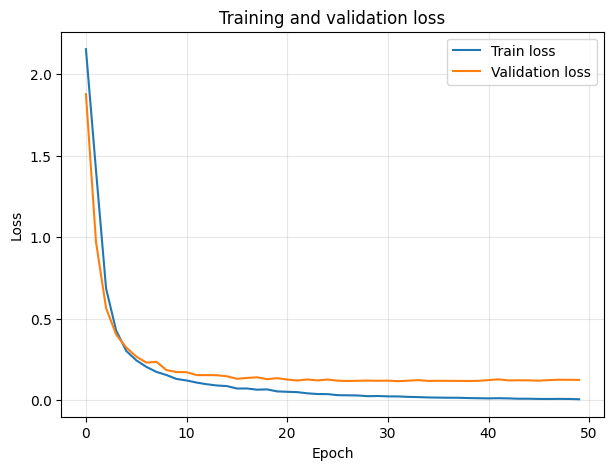

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_training_validation_loss.png


In [16]:
# ------------------------------------------------------------
# 10 · Plot training curves
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "03_training_validation_loss.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [17]:
# ------------------------------------------------------------
# 11 · Evaluate on test set
# ------------------------------------------------------------

test_metrics = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['accuracy']:.4f}")

Test loss     : 0.0819
Test accuracy : 0.9778


In [18]:
"""
## 5. Tabla de predicciones

Para analizar errores de forma sistemática conviene construir una tabla donde cada fila representa una muestra del conjunto de test.

La tabla incluirá:

- índice de la muestra,
- etiqueta real,
- predicción del modelo,
- confianza de la predicción,
- si la predicción fue correcta o incorrecta.

Esta tabla es muy útil porque permite ordenar, filtrar, guardar y revisar casos problemáticos.
"""

'\n## 5. Tabla de predicciones\n\nPara analizar errores de forma sistemática conviene construir una tabla donde cada fila representa una muestra del conjunto de test.\n\nLa tabla incluirá:\n\n- índice de la muestra,\n- etiqueta real,\n- predicción del modelo,\n- confianza de la predicción,\n- si la predicción fue correcta o incorrecta.\n\nEsta tabla es muy útil porque permite ordenar, filtrar, guardar y revisar casos problemáticos.\n'

In [19]:
# ------------------------------------------------------------
# 12 · Build prediction-level evaluation table
# ------------------------------------------------------------

y_true = test_metrics["labels"]
y_pred = test_metrics["predictions"]
probs = test_metrics["probabilities"]

confidence = probs.max(axis=1)

evaluation_df = pd.DataFrame({
    "sample_index": np.arange(len(y_true)),
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": confidence,
    "correct": y_true == y_pred
})

evaluation_df.head()

,sample_index,true_label,predicted_label,confidence,correct
0,0,6,6,0.999822,True
1,1,1,1,0.999840,True
2,2,8,8,0.993810,True
3,3,1,1,0.999761,True
4,4,3,3,0.999945,True


In [20]:
# ------------------------------------------------------------
# 13 · Summary of correct and incorrect predictions
# ------------------------------------------------------------

n_total = len(evaluation_df)
n_correct = evaluation_df["correct"].sum()
n_errors = n_total - n_correct

print(f"Total samples       : {n_total}")
print(f"Correct predictions : {n_correct}")
print(f"Incorrect predictions: {n_errors}")
print(f"Accuracy            : {n_correct / n_total:.4f}")

Total samples       : 270
Correct predictions : 264
Incorrect predictions: 6
Accuracy            : 0.9778


In [21]:
# ------------------------------------------------------------
# 14 · Save prediction-level table
# ------------------------------------------------------------

evaluation_path = RESULTS_DIR / "03_prediction_level_error_analysis.csv"

evaluation_df.to_csv(evaluation_path, index=False)

print(f"Evaluation table saved to: {evaluation_path}")

Evaluation table saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\03_prediction_level_error_analysis.csv


In [22]:
"""
## 6. Errores de clasificación

Ahora vamos a separar las muestras mal clasificadas.

No todos los errores son igualmente importantes. En particular, nos interesan mucho los errores con alta confianza, 
porque indican que el modelo está seguro de una predicción incorrecta.
"""

'\n## 6. Errores de clasificación\n\nAhora vamos a separar las muestras mal clasificadas.\n\nNo todos los errores son igualmente importantes. En particular, nos interesan mucho los errores con alta confianza, \nporque indican que el modelo está seguro de una predicción incorrecta.\n'

In [23]:
# ------------------------------------------------------------
# 15 · Extract incorrect predictions
# ------------------------------------------------------------

errors_df = evaluation_df[~evaluation_df["correct"]].copy()

errors_df = errors_df.sort_values("confidence", ascending=False)

print("Number of errors:", len(errors_df))

errors_df.head(10)

Number of errors: 6


,sample_index,true_label,predicted_label,confidence,correct
121,121,8,1,0.995208,False
107,107,8,2,0.873038,False
168,168,6,8,0.868330,False
36,36,2,1,0.864314,False
218,218,0,4,0.833121,False
96,96,8,1,0.825797,False


In [24]:
# ------------------------------------------------------------
# 16 · Save errors table
# ------------------------------------------------------------

errors_path = RESULTS_DIR / "03_errors_only.csv"

errors_df.to_csv(errors_path, index=False)

print(f"Errors table saved to: {errors_path}")

Errors table saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\03_errors_only.csv


In [25]:
"""
## 7. Errores con alta confianza

Un error con baja confianza puede indicar que la muestra era ambigua para el modelo.

Un error con alta confianza es más preocupante, porque el modelo asigna una probabilidad alta a una clase incorrecta.

En scientific imaging, estos casos pueden revelar:

- artefactos que el modelo interpreta mal,
- clases visualmente parecidas,
- etiquetas dudosas,
- muestras fuera de distribución,
- sesgos en el dataset.
"""

'\n## 7. Errores con alta confianza\n\nUn error con baja confianza puede indicar que la muestra era ambigua para el modelo.\n\nUn error con alta confianza es más preocupante, porque el modelo asigna una probabilidad alta a una clase incorrecta.\n\nEn scientific imaging, estos casos pueden revelar:\n\n- artefactos que el modelo interpreta mal,\n- clases visualmente parecidas,\n- etiquetas dudosas,\n- muestras fuera de distribución,\n- sesgos en el dataset.\n'

In [26]:
# ------------------------------------------------------------
# 17 · High-confidence errors
# ------------------------------------------------------------

high_conf_threshold = 0.90

high_conf_errors_df = errors_df[errors_df["confidence"] >= high_conf_threshold].copy()

print(f"High-confidence threshold: {high_conf_threshold}")
print(f"Number of high-confidence errors: {len(high_conf_errors_df)}")

high_conf_errors_df

High-confidence threshold: 0.9
Number of high-confidence errors: 1


,sample_index,true_label,predicted_label,confidence,correct
121,121,8,1,0.995208,False


In [27]:
# ------------------------------------------------------------
# 18 · Errors by true class
# ------------------------------------------------------------

errors_by_true_class = (
    errors_df
    .groupby("true_label")
    .size()
    .reset_index(name="num_errors")
)

errors_by_true_class["true_label"] = errors_by_true_class["true_label"].astype(str)

errors_by_true_class

,true_label,num_errors
0,0,1
1,2,1
2,6,1
3,8,3


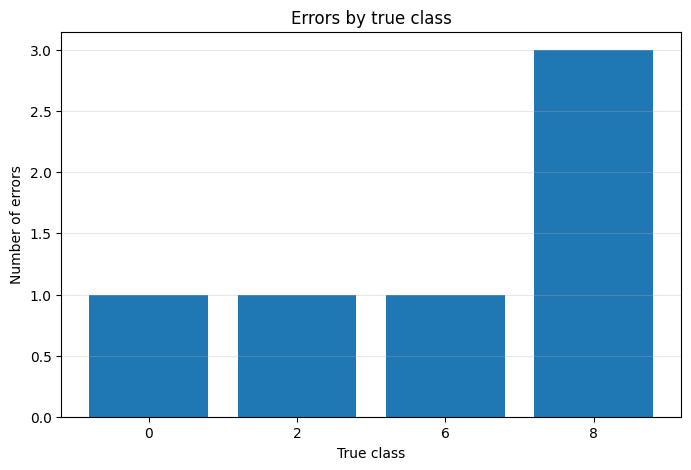

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_errors_by_true_class.png


In [28]:
# ------------------------------------------------------------
# 19 · Plot errors by true class
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(errors_by_true_class["true_label"], errors_by_true_class["num_errors"])

plt.xlabel("True class")
plt.ylabel("Number of errors")
plt.title("Errors by true class")
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "03_errors_by_true_class.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [29]:
# ------------------------------------------------------------
# 20 · Errors by predicted class
# ------------------------------------------------------------

errors_by_predicted_class = (
    errors_df
    .groupby("predicted_label")
    .size()
    .reset_index(name="num_errors")
)

errors_by_predicted_class["predicted_label"] = errors_by_predicted_class["predicted_label"].astype(str)

errors_by_predicted_class

,predicted_label,num_errors
0,1,3
1,2,1
2,4,1
3,8,1


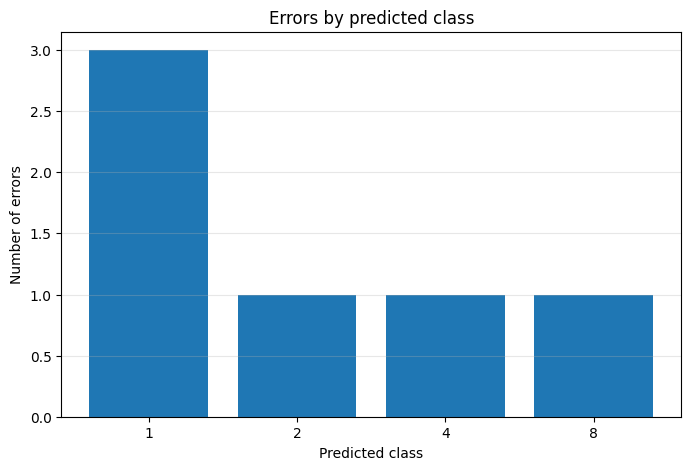

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_errors_by_predicted_class.png


In [30]:
# ------------------------------------------------------------
# 21 · Plot errors by predicted class
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(errors_by_predicted_class["predicted_label"], errors_by_predicted_class["num_errors"])

plt.xlabel("Predicted class")
plt.ylabel("Number of errors")
plt.title("Errors by predicted class")
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "03_errors_by_predicted_class.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [31]:
"""
## 8. Errores por clase

Analizar errores por clase ayuda a detectar si el modelo falla de forma uniforme o si ciertas clases concentran la mayor parte de los problemas.

Esto es importante porque una accuracy global alta puede ocultar errores sistemáticos.

En este caso, nos interesa especialmente revisar si algunas clases son confundidas con frecuencia, por ejemplo:

"text
8 → 1
"""

'\n## 8. Errores por clase\n\nAnalizar errores por clase ayuda a detectar si el modelo falla de forma uniforme o si ciertas clases concentran la mayor parte de los problemas.\n\nEsto es importante porque una accuracy global alta puede ocultar errores sistemáticos.\n\nEn este caso, nos interesa especialmente revisar si algunas clases son confundidas con frecuencia, por ejemplo:\n\n"text\n8 → 1\n'

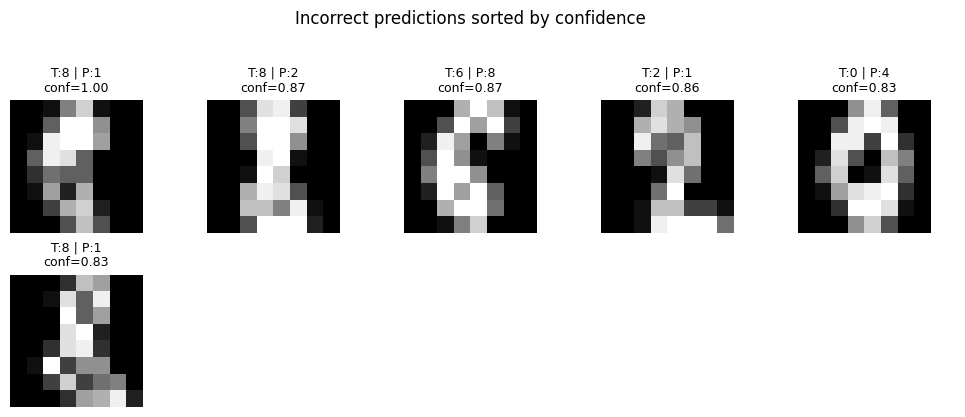

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_incorrect_predictions_sorted_by_confidence.png


In [32]:

#Ahora visualizamos directamente los errores.

## Celda 31 — Código

#python
# ------------------------------------------------------------
# 22 · Visualize incorrect predictions
# ------------------------------------------------------------

n_errors_to_show = min(10, len(errors_df))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flat

for ax_idx, (_, row) in enumerate(errors_df.head(n_errors_to_show).iterrows()):
    sample_idx = int(row["sample_index"])
    true_label = int(row["true_label"])
    pred_label = int(row["predicted_label"])
    conf = row["confidence"]

    image = X_test[sample_idx].reshape(8, 8)

    axes[ax_idx].imshow(image, cmap="gray")
    axes[ax_idx].set_title(
        f"T:{true_label} | P:{pred_label}\nconf={conf:.2f}",
        fontsize=9
    )
    axes[ax_idx].axis("off")

for ax in axes[n_errors_to_show:]:
    ax.axis("off")

plt.suptitle("Incorrect predictions sorted by confidence", y=1.03)
plt.tight_layout()

out = FIGURES_DIR / "03_incorrect_predictions_sorted_by_confidence.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

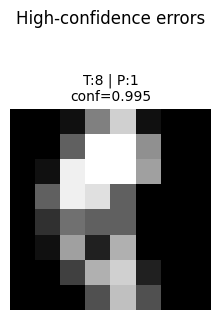

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_high_confidence_errors.png


In [33]:
# ------------------------------------------------------------
# 23 · Visualize high-confidence errors
# ------------------------------------------------------------

if len(high_conf_errors_df) > 0:
    n_high_conf_errors = len(high_conf_errors_df)

    fig, axes = plt.subplots(1, n_high_conf_errors, figsize=(3 * n_high_conf_errors, 3))

    if n_high_conf_errors == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, high_conf_errors_df.iterrows()):
        sample_idx = int(row["sample_index"])
        true_label = int(row["true_label"])
        pred_label = int(row["predicted_label"])
        conf = row["confidence"]

        image = X_test[sample_idx].reshape(8, 8)

        ax.imshow(image, cmap="gray")
        ax.set_title(
            f"T:{true_label} | P:{pred_label}\nconf={conf:.3f}",
            fontsize=10
        )
        ax.axis("off")

    plt.suptitle("High-confidence errors", y=1.05)
    plt.tight_layout()

    out = FIGURES_DIR / "03_high_confidence_errors.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure saved to: {out}")

else:
    print("No high-confidence errors found.")

In [34]:
"""
## 9. Interpretación de errores de alta confianza

El error de alta confianza es especialmente importante.

En este ejemplo, el modelo clasificó una muestra real de clase "8" como clase "1" con confianza muy alta.

Este tipo de caso puede indicar que:

- la muestra es visualmente ambigua,
- el dígito está incompleto o deformado,
- la clase predicha comparte rasgos visuales con la clase real,
- el modelo aprendió una regla demasiado simplificada,
- la imagen puede representar un caso límite.

En imágenes científicas, un error de alta confianza podría ser crítico, por ejemplo si un defecto, grieta o fase minoritaria es 
clasificado como una región normal.
"""

'\n## 9. Interpretación de errores de alta confianza\n\nEl error de alta confianza es especialmente importante.\n\nEn este ejemplo, el modelo clasificó una muestra real de clase "8" como clase "1" con confianza muy alta.\n\nEste tipo de caso puede indicar que:\n\n- la muestra es visualmente ambigua,\n- el dígito está incompleto o deformado,\n- la clase predicha comparte rasgos visuales con la clase real,\n- el modelo aprendió una regla demasiado simplificada,\n- la imagen puede representar un caso límite.\n\nEn imágenes científicas, un error de alta confianza podría ser crítico, por ejemplo si un defecto, grieta o fase minoritaria es \nclasificado como una región normal.\n'

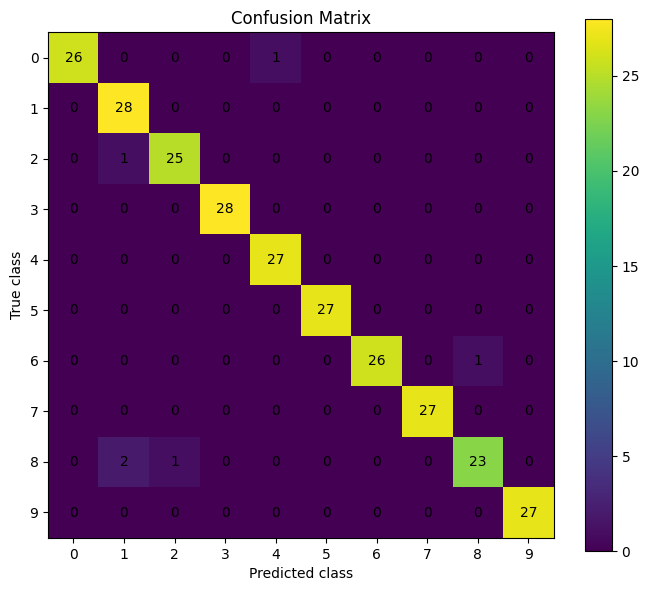

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_confusion_matrix.png


In [35]:
# ------------------------------------------------------------
# 24 · Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

out = FIGURES_DIR / "03_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

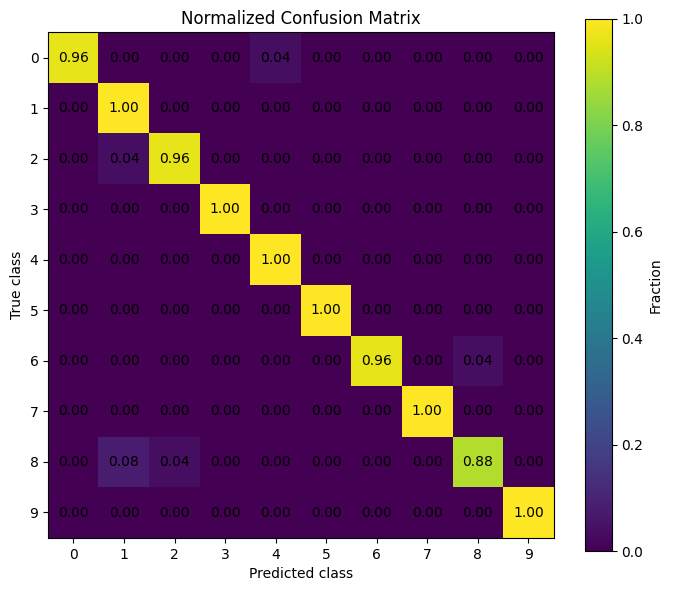

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_normalized_confusion_matrix.png


In [36]:
# ------------------------------------------------------------
# 25 · Normalized confusion matrix
# ------------------------------------------------------------

cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, vmin=0, vmax=1)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar(label="Fraction")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

out = FIGURES_DIR / "03_normalized_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [37]:
"""
## 10. Matriz de confusión normalizada

La matriz de confusión absoluta muestra el número de errores.

La matriz normalizada muestra la fracción de cada clase verdadera que fue clasificada en cada categoría.

Esto es útil cuando las clases tienen distinta cantidad de muestras.

En scientific imaging, esta visualización permite identificar si una clase minoritaria tiene bajo rendimiento aunque la accuracy global sea alta.
"""

'\n## 10. Matriz de confusión normalizada\n\nLa matriz de confusión absoluta muestra el número de errores.\n\nLa matriz normalizada muestra la fracción de cada clase verdadera que fue clasificada en cada categoría.\n\nEsto es útil cuando las clases tienen distinta cantidad de muestras.\n\nEn scientific imaging, esta visualización permite identificar si una clase minoritaria tiene bajo rendimiento aunque la accuracy global sea alta.\n'

In [38]:
# ------------------------------------------------------------
# 26 · Confusion pairs
# ------------------------------------------------------------

confusion_pairs = []

for true_class in range(cm.shape[0]):
    for pred_class in range(cm.shape[1]):
        if true_class != pred_class and cm[true_class, pred_class] > 0:
            confusion_pairs.append({
                "true_label": true_class,
                "predicted_label": pred_class,
                "count": cm[true_class, pred_class],
                "fraction_of_true_class": cm_normalized[true_class, pred_class]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    by="count",
    ascending=False
)

confusion_pairs_df

,true_label,predicted_label,count,fraction_of_true_class
3,8,1,2,0.076923
0,0,4,1,0.037037
1,2,1,1,0.038462
2,6,8,1,0.037037
4,8,2,1,0.038462


In [39]:
# ------------------------------------------------------------
# 27 · Save confusion pairs
# ------------------------------------------------------------

confusion_pairs_path = RESULTS_DIR / "03_confusion_pairs.csv"

confusion_pairs_df.to_csv(confusion_pairs_path, index=False)

print(f"Confusion pairs saved to: {confusion_pairs_path}")

Confusion pairs saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\03_confusion_pairs.csv


In [40]:
"""
## 11. Pares de confusión

Los pares de confusión permiten identificar errores específicos del tipo:

"text
clase real → clase predicha
"""

'\n## 11. Pares de confusión\n\nLos pares de confusión permiten identificar errores específicos del tipo:\n\n"text\nclase real → clase predicha\n'

In [41]:
"""
## 12. Análisis de confianza

La confianza del modelo se calcula como la probabilidad máxima después de aplicar "softmax".

Comparar la confianza entre aciertos y errores permite detectar comportamientos importantes:

- errores de baja confianza: el modelo estaba inseguro,
- errores de alta confianza: el modelo estaba seguro pero equivocado,
- aciertos de baja confianza: casos difíciles o ambiguos.

En aplicaciones científicas, los errores de alta confianza suelen ser los más importantes para inspección manual.
"""

'\n## 12. Análisis de confianza\n\nLa confianza del modelo se calcula como la probabilidad máxima después de aplicar "softmax".\n\nComparar la confianza entre aciertos y errores permite detectar comportamientos importantes:\n\n- errores de baja confianza: el modelo estaba inseguro,\n- errores de alta confianza: el modelo estaba seguro pero equivocado,\n- aciertos de baja confianza: casos difíciles o ambiguos.\n\nEn aplicaciones científicas, los errores de alta confianza suelen ser los más importantes para inspección manual.\n'

In [42]:
# ------------------------------------------------------------
# 28 · Confidence summary
# ------------------------------------------------------------

confidence_summary = evaluation_df.groupby("correct")["confidence"].describe()

confidence_summary

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,6.0,0.876635,0.061272,0.825797,0.840919,0.866322,0.871861,0.995208
True,264.0,0.982839,0.064552,0.460898,0.998455,0.999908,0.999992,1.000000


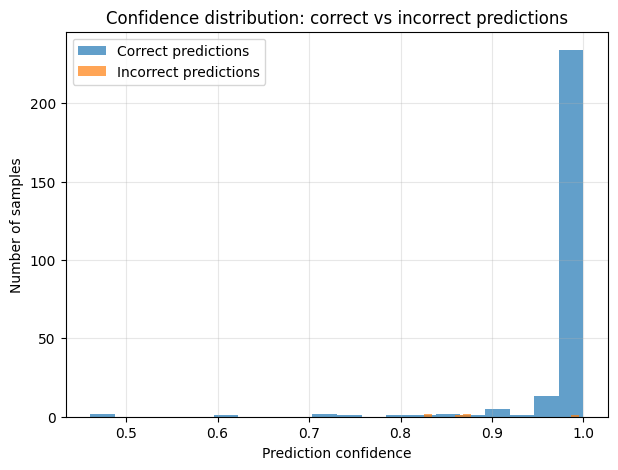

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\03_confidence_distribution_correct_vs_incorrect.png


In [43]:
# ------------------------------------------------------------
# 29 · Confidence distribution for correct and incorrect predictions
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.hist(
    evaluation_df.loc[evaluation_df["correct"], "confidence"],
    bins=20,
    alpha=0.7,
    label="Correct predictions"
)

plt.hist(
    evaluation_df.loc[~evaluation_df["correct"], "confidence"],
    bins=20,
    alpha=0.7,
    label="Incorrect predictions"
)

plt.xlabel("Prediction confidence")
plt.ylabel("Number of samples")
plt.title("Confidence distribution: correct vs incorrect predictions")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "03_confidence_distribution_correct_vs_incorrect.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [44]:
# ------------------------------------------------------------
# 30 · Least confident predictions
# ------------------------------------------------------------

least_confident_df = evaluation_df.sort_values("confidence", ascending=True).head(10)

least_confident_df

,sample_index,true_label,predicted_label,confidence,correct
11,11,9,9,0.460898,True
179,179,9,9,0.482090,True
138,138,1,1,0.598578,True
257,257,1,1,0.703645,True
8,8,9,9,0.711482,True
110,110,9,9,0.742679,True
199,199,8,8,0.791122,True
197,197,7,7,0.813310,True
96,96,8,1,0.825797,False
218,218,0,4,0.833121,False


In [45]:
# ------------------------------------------------------------
# 31 · Most confident incorrect predictions
# ------------------------------------------------------------

most_confident_errors_df = errors_df.sort_values("confidence", ascending=False).head(10)

most_confident_errors_df

,sample_index,true_label,predicted_label,confidence,correct
121,121,8,1,0.995208,False
107,107,8,2,0.873038,False
168,168,6,8,0.868330,False
36,36,2,1,0.864314,False
218,218,0,4,0.833121,False
96,96,8,1,0.825797,False


In [46]:
"""
## 13. Interpretación final del análisis de errores

El análisis muestra que el modelo tiene una accuracy global alta, pero aun así presenta errores específicos.

El caso más relevante es un error de alta confianza:

"text
true_label = 8
predicted_label = 1
confidence ≈ 0.995
"""

'\n## 13. Interpretación final del análisis de errores\n\nEl análisis muestra que el modelo tiene una accuracy global alta, pero aun así presenta errores específicos.\n\nEl caso más relevante es un error de alta confianza:\n\n"text\ntrue_label = 8\npredicted_label = 1\nconfidence ≈ 0.995\n'

In [47]:

## Celda 46 — Código

#python
# ------------------------------------------------------------
# 32 · Save trained model
# ------------------------------------------------------------

model_path = MODELS_DIR / "03_error_analysis_mlp.pt"

torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\models\03_error_analysis_mlp.pt


In [48]:
"""
# Conclusión final

En este notebook construimos un flujo completo de análisis de errores para modelos de clasificación de imágenes.

Trabajamos con:

- tabla de predicciones por muestra,
- separación de aciertos y errores,
- errores con alta confianza,
- errores por clase verdadera,
- errores por clase predicha,
- matriz de confusión,
- matriz de confusión normalizada,
- pares de confusión,
- distribución de confianza.

Este tipo de análisis es especialmente importante en scientific imaging, donde los errores pueden tener significado físico o experimental.

La idea central es pasar de una pregunta simple:

#text
¿Cuál es la accuracy?
"""

'\n# Conclusión final\n\nEn este notebook construimos un flujo completo de análisis de errores para modelos de clasificación de imágenes.\n\nTrabajamos con:\n\n- tabla de predicciones por muestra,\n- separación de aciertos y errores,\n- errores con alta confianza,\n- errores por clase verdadera,\n- errores por clase predicha,\n- matriz de confusión,\n- matriz de confusión normalizada,\n- pares de confusión,\n- distribución de confianza.\n\nEste tipo de análisis es especialmente importante en scientific imaging, donde los errores pueden tener significado físico o experimental.\n\nLa idea central es pasar de una pregunta simple:\n\n#text\n¿Cuál es la accuracy?\n'

In [49]:

## Celda 48 — Código final

#python
# ------------------------------------------------------------
# 33 · End of notebook
# ------------------------------------------------------------

print("Notebook 03 completed successfully.")

Notebook 03 completed successfully.
